# 📈 Advertising Spend → Sales Prediction 




In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import joblib
import os
sns.set_theme(style="whitegrid", palette="Set2")

import warnings
warnings.filterwarnings("ignore")


## 2. Data Loading

In [3]:
df = pd.read_csv('Advertising.csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,200.0,100.5000,57.879185,1.0,50.750,100.50,150.250,200.0
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Duplicate rows: 0


## 3.EDA



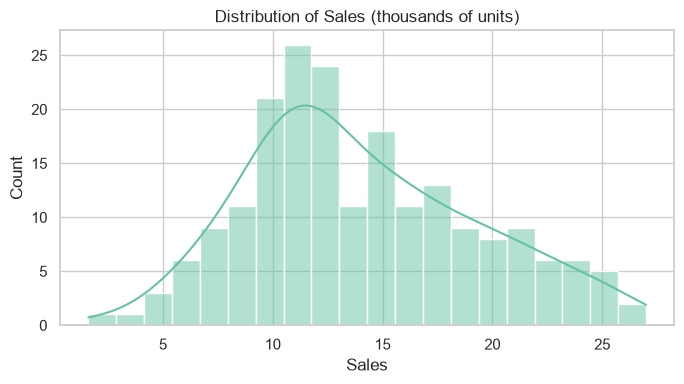

In [7]:
plt.figure(figsize=(7, 4))
sns.histplot(df["Sales"], bins=20, kde=True)
plt.title("Distribution of Sales (thousands of units)")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()


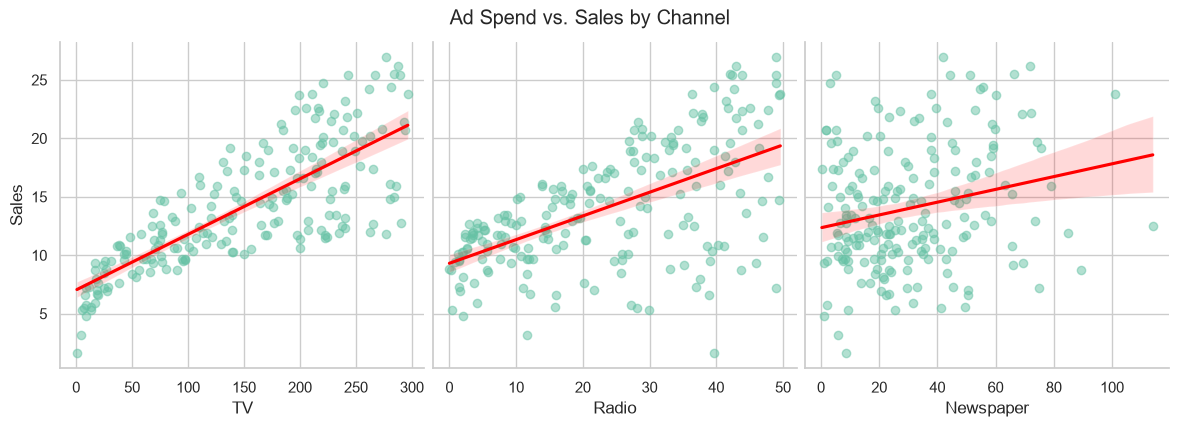

In [8]:
sns.pairplot(df, y_vars=["Sales"], x_vars=["TV", "Radio", "Newspaper"], height=4, kind="reg",
             plot_kws={"scatter_kws": {"alpha": 0.5}, "line_kws": {"color": "red"}})

plt.suptitle("Ad Spend vs. Sales by Channel", y=1.05)
plt.show()


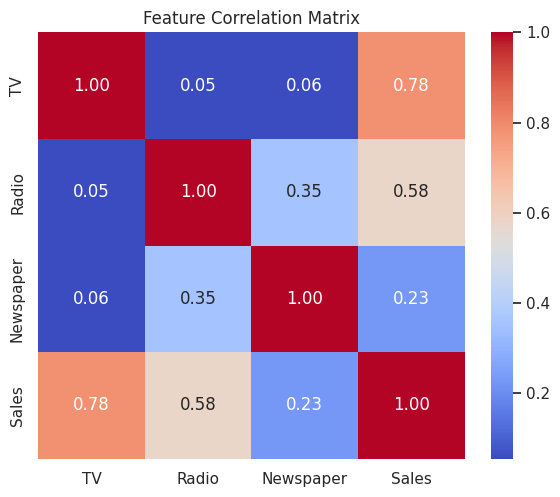

In [8]:
# Correlation heatmap
plt.figure(figsize=(6, 5))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 4. Preprocessing

In [10]:
# Feature / target split
X = df.drop(columns=["Sales"])
y = df["Sales"]

numeric_features = ["TV", "Radio", "Newspaper"]

X.head()


,Unnamed: 0,TV,Radio,Newspaper
0,1,230.1,37.8,69.2
1,2,44.5,39.3,45.1
2,3,17.2,45.9,69.3
3,4,151.5,41.3,58.5
4,5,180.8,10.8,58.4


In [15]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")


Training samples: 160
Testing samples:  40


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric_scaler", StandardScaler(), numeric_features),
    ],
    remainder="drop"
)

print("ColumnTransformer configured:")
preprocessor


ColumnTransformer configured:


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

##  Model Building

In [17]:
regressors = {
    "Linear Regression": LinearRegression(fit_intercept=True,copy_X=True,n_jobs=None,positive=False),
    "Ridge Regression": Ridge(alpha=1.0,fit_intercept=True,solver="auto", random_state=42),
    "Lasso Regression": Lasso(alpha=1.0,fit_intercept=True,max_iter=1000,tol=0.0001,random_state=42),
    "Decision Tree": DecisionTreeRegressor(criterion="squared_error", max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features=None, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, criterion="squared_error", max_depth=None, min_samples_split=2, min_samples_leaf=1,max_features=1.0,bootstrap=True, random_state=42,n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,max_depth=3,min_samples_split=2,min_samples_leaf=1,subsample=1.0,random_state=42),
    "Support Vector Regressor": SVR(kernel="rbf",C=1.0, epsilon=0.1, gamma="scale"),
}

pipelines = {
    name: Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", reg),
    ])
    for name, reg in regressors.items()
}

results = []

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")

    results.append({
        "Model": name,
        "Test R2": r2_score(y_test, y_pred),
        "Test MAE": mean_absolute_error(y_test, y_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "CV Mean R2": cv_scores.mean(),
        "CV Std": cv_scores.std(),
    })

results_df = pd.DataFrame(results).sort_values(by="Test R2", ascending=False).reset_index(drop=True)
results_df


,Model,Test R2,Test MAE,Test RMSE,CV Mean R2,CV Std
0,Gradient Boosting,0.983140,0.618119,0.729496,0.969815,0.012211
1,Random Forest,0.981799,0.629838,0.757945,0.970037,0.011186
2,Decision Tree,0.931091,0.985000,1.474788,0.937992,0.021899
3,Support Vector Regressor,0.909322,1.162139,1.691777,0.839154,0.040663
4,Linear Regression,0.899438,1.460757,1.781600,0.859488,0.084559
5,Ridge Regression,0.898803,1.464301,1.787220,0.859656,0.083037
6,Lasso Regression,0.817997,1.854928,2.396806,0.782342,0.038836


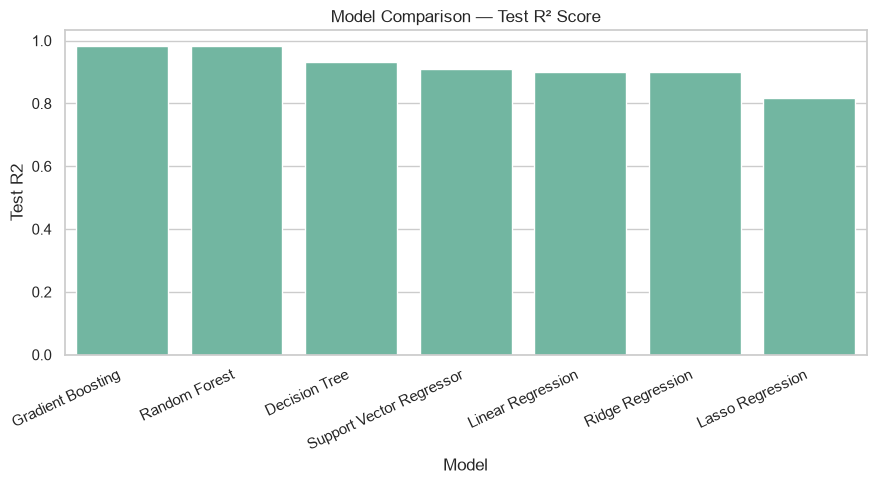

In [18]:
# Visual comparison of model performance
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="Model", y="Test R2")
plt.xticks(rotation=25, ha="right")
plt.title("Model Comparison — Test R\u00b2 Score")
plt.tight_layout()
plt.show()


## 6. Model Evaluation


In [19]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = pipelines[best_model_name]
print(f"Best performing model: {best_model_name}")

y_pred_best = best_pipeline.predict(X_test)

print(f"R2 Score : {r2_score(y_test, y_pred_best):.4f}")
print(f"MAE      : {mean_absolute_error(y_test, y_pred_best):.4f} (thousand units)")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f} (thousand units)")


Best performing model: Gradient Boosting
R2 Score : 0.9831
MAE      : 0.6181 (thousand units)
RMSE     : 0.7295 (thousand units)


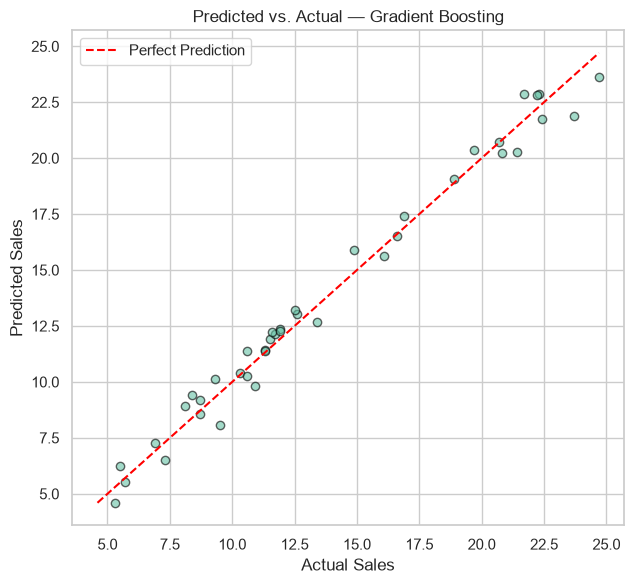

In [20]:
# Predicted vs Actual
plt.figure(figsize=(6.5, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, edgecolor="k")
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, "r--", label="Perfect Prediction")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Predicted vs. Actual — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()


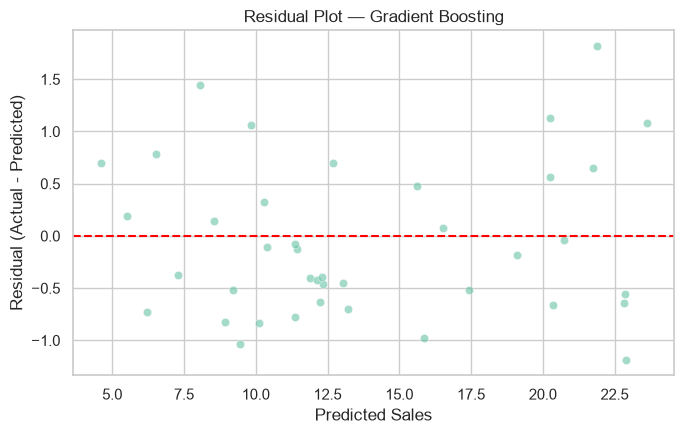

In [22]:
# Residual plot — should show no obvious pattern if the model fits well
residuals = y_test - y_pred_best

plt.figure(figsize=(7, 4.5))
sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Plot — {best_model_name}")
plt.tight_layout()
plt.show()


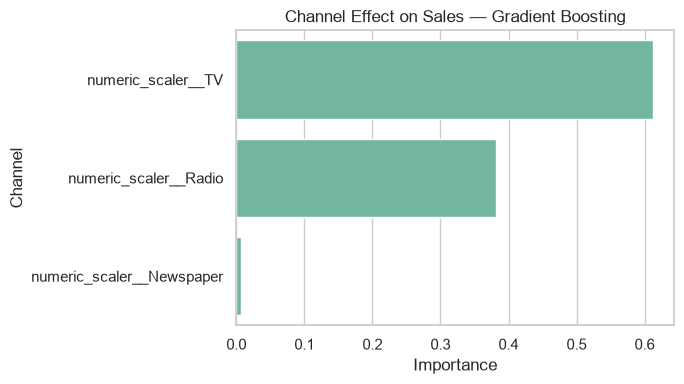

,Channel,Importance
0,numeric_scaler__TV,0.612579
1,numeric_scaler__Radio,0.380914
2,numeric_scaler__Newspaper,0.006507


In [ ]:
best_model = best_pipeline.named_steps["model"]
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Channel": feature_names,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)
    value_col = "Importance"
elif hasattr(best_model, "coef_"):
    importance_df = pd.DataFrame({
        "Channel": feature_names,
        "Coefficient": best_model.coef_
    }).sort_values(by="Coefficient", ascending=False)
    value_col = "Coefficient"
else:
    importance_df = None

if importance_df is not None:
    plt.figure(figsize=(7, 4))
    sns.barplot(data=importance_df, x=value_col, y="Channel")
    plt.title(f"Channel Effect on Sales — {best_model_name}")
    plt.tight_layout()
    plt.show()
    display(importance_df)
else:
    print(f"{best_model_name} does not expose importances or coefficients directly.")


## 8. Final Model 


In [28]:
os.makedirs("models", exist_ok=True)
model_path = "models/sales_prediction_model.pkl"

joblib.dump(best_pipeline, model_path)
print(f"Best model saved successfully!")
print(f"Model: {best_model_name}")
print(f"Path: {model_path}")


Best model saved successfully!
Model: Gradient Boosting
Path: models/sales_prediction_model.pkl
